# interaction_only[HF] — Version 2 Final Trial

This notebook is the **last Version 2 trial** for the Hockey Fight interaction-only video-to-graph violence detection pipeline.

It keeps the same local raw-video pipeline:

Raw videos → YOLO11x person detection → IoU tracking → interaction-only spatiotemporal graphs → edge-aware graph transformer → fight / non-fight classification.

## What is new in this final trial?

Compared with V2.1/V2.2, this notebook tries stronger but still controlled improvements:

1. **Automatic timestamped output folder creation** — no need to manually create output folders.
2. **V2.1 scaled motion node features** — keeps `[cx, cy, w, h, t_norm, vx_scaled, vy_scaled, speed_scaled, area, aspect_ratio_scaled, conf]`.
3. **Richer edge attributes** — updates edges from 2D to 4D:
   - `dt_norm`
   - `dist_norm`
   - `edge_type` where 0 = spatial edge and 1 = temporal edge
   - `direction` where temporal forward = +1, temporal backward = -1, spatial = 0
4. **Feature-gated model** — separates base box/time features from motion/auxiliary features and learns how much to trust the motion features.
5. **Residual TransformerConv blocks** — improves stability.
6. **Label smoothing + gradient clipping** — reduces overconfident fitting.
7. **Precision-aware checkpoint score** — helps reduce false alarms.
8. **Validation threshold tuning with precision constraint** — chooses a threshold that tries to keep validation precision high while maintaining recall.

Dataset path is already set to:

```text
C:\Violence detection\datasets\Hockey fight\data
```



In [1]:
# Cell 1 — Optional dependency installation
# Uncomment only if your local environment is missing packages.

# !pip install ultralytics opencv-python pandas numpy matplotlib scikit-learn tqdm
# !pip install torch torchvision torchaudio
# !pip install torch-geometric




In [2]:
# Cell 2 — Imports and reproducibility
import os, json, math, random, warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from datetime import datetime
from typing import Optional, List, Dict, Any

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, classification_report, f1_score
)

from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import TransformerConv, global_mean_pool, global_max_pool

warnings.filterwarnings("ignore")
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))




c:\Users\server\anaconda3\envs\csit\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 3090


In [3]:
# Cell 3 — Main configuration with automatic output folder creation

@dataclass
class Config:
    # Dataset path provided by you.
    dataset_root: str = r"C:\Violence detection\datasets\Hockey fight\data"

    # Base output folder. The notebook creates this automatically.
    # A timestamped run folder will be created inside it.
    base_output_dir: str = r"C:\Violence detection\sara_elwakeel\we are really there\we are really there 2\auto_outputs"

    experiment_name: str = "interaction_only[HF]_2_final_trial"
    version_name: str = "v23_final_feature_gated_edges"
    yolo_weights: str = "yolo11x.pt"

    expected_node_dim: int = 11
    expected_edge_dim: int = 4

    yolo_conf: float = 0.25
    yolo_nms_iou: float = 0.30
    person_class_id: int = 0

    tracking_iou_threshold: float = 0.50
    max_lost: int = 10

    temporal_window: int = 2
    spatial_threshold: float = 0.30
    alpha_t: float = 5.0
    alpha_d: float = 0.30

    motion_clip_xy: float = 0.20
    motion_clip_speed: float = 0.30
    aspect_ratio_clip: float = 5.0

    target_fps: Optional[float] = None

    min_norm_area: float = 0.0
    max_norm_area: float = 1.0
    min_aspect_ratio: float = 0.0
    max_aspect_ratio: float = 999.0

    test_size: float = 0.15
    val_size: float = 0.15
    batch_size: int = 8
    epochs: int = 40
    lr: float = 1e-3
    weight_decay: float = 1e-4
    hidden_dim: int = 128
    heads: int = 4
    dropout: float = 0.30

    # Final-trial training stabilization.
    label_smoothing: float = 0.03
    grad_clip_norm: float = 2.0
    min_epochs_before_checkpoint: int = 5

    # Precision-aware checkpointing.
    # This gives F1 the largest weight, but also rewards precision to reduce false alarms.
    checkpoint_f1_weight: float = 0.45
    checkpoint_auc_weight: float = 0.25
    checkpoint_precision_weight: float = 0.20
    checkpoint_acc_weight: float = 0.10

    use_scheduler: bool = True
    early_stopping_patience: Optional[int] = None

    # Threshold tuning constraint.
    threshold_min_precision: float = 0.90
    threshold_min_recall: float = 0.85

CFG = Config()

# Important: if you rerun this cell in the same kernel, it keeps the same folder.
# Restart the kernel to create a new timestamped run folder.
if "RUN_TAG" not in globals():
    RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")

BASE_OUTPUT_DIR = Path(CFG.base_output_dir)
OUTPUT_ROOT = BASE_OUTPUT_DIR / f"{CFG.experiment_name}_{RUN_TAG}"
GRAPH_DIR = OUTPUT_ROOT / "graphs"
RUNS_DIR = OUTPUT_ROOT / "training_outputs"
PLOTS_DIR = OUTPUT_ROOT / "plots"

INDEX_CSV = OUTPUT_ROOT / "index.csv"
CLEAN_INDEX_CSV = OUTPUT_ROOT / "clean_verified_index.csv"
CONFIG_JSON = OUTPUT_ROOT / "config_v23_final_trial.json"

for p in [BASE_OUTPUT_DIR, OUTPUT_ROOT, GRAPH_DIR, RUNS_DIR, PLOTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

output_name = OUTPUT_ROOT.name.lower()
assert ("final" in output_name or "v23" in output_name or "interaction_only" in output_name), \
    f"Output folder does not look like the final Version 2 trial folder: {OUTPUT_ROOT}"

with open(CONFIG_JSON, "w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2)

print("Dataset root :", CFG.dataset_root)
print("Output root  :", OUTPUT_ROOT)
print("Graph dir    :", GRAPH_DIR)
print("Training dir :", RUNS_DIR)
print("Plots dir    :", PLOTS_DIR)
print("Config saved :", CONFIG_JSON)
print("Run tag      :", RUN_TAG)
print("Version      :", CFG.version_name)
print("Node dim     :", CFG.expected_node_dim)
print("Edge dim     :", CFG.expected_edge_dim)






Dataset root : C:\Violence detection\datasets\Hockey fight\data
Output root  : C:\Violence detection\sara_elwakeel\we are really there\we are really there 2\auto_outputs\interaction_only[HF]_2_final_trial_20260419_234156
Graph dir    : C:\Violence detection\sara_elwakeel\we are really there\we are really there 2\auto_outputs\interaction_only[HF]_2_final_trial_20260419_234156\graphs
Training dir : C:\Violence detection\sara_elwakeel\we are really there\we are really there 2\auto_outputs\interaction_only[HF]_2_final_trial_20260419_234156\training_outputs
Plots dir    : C:\Violence detection\sara_elwakeel\we are really there\we are really there 2\auto_outputs\interaction_only[HF]_2_final_trial_20260419_234156\plots
Config saved : C:\Violence detection\sara_elwakeel\we are really there\we are really there 2\auto_outputs\interaction_only[HF]_2_final_trial_20260419_234156\config_v23_final_trial.json
Run tag      : 20260419_234156
Version      : v23_final_feature_gated_edges
Node dim     : 11

In [4]:
# Cell 4 — Dataset discovery and label inference
VIDEO_EXTS = {".avi", ".mp4", ".mov", ".mkv", ".wmv", ".mpeg", ".mpg"}

def infer_label_from_path(path: Path) -> int:
    parts = [p.lower() for p in path.parts]
    text = " ".join(parts)
    negative_keywords = ["nofight", "nofights", "nonfight", "non-fight", "normal", "negative", "no_fight"]
    positive_keywords = ["fight", "fights", "violent", "violence", "positive"]
    if any(k in text for k in negative_keywords):
        return 0
    if any(k in text for k in positive_keywords):
        return 1
    raise ValueError(f"Could not infer label from path: {path}")

def discover_videos(dataset_root: str) -> pd.DataFrame:
    root = Path(dataset_root)
    assert root.exists(), f"Dataset root does not exist: {root}"
    rows = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in VIDEO_EXTS:
            label = infer_label_from_path(p)
            rows.append({
                "video_id": p.stem,
                "video_path": str(p),
                "label": label,
                "class_name": "fight" if label == 1 else "nonfight",
            })
    return pd.DataFrame(rows).sort_values(["label", "video_path"]).reset_index(drop=True)

videos_df = discover_videos(CFG.dataset_root)
print("Total videos:", len(videos_df))
display(videos_df.head())
print("\nLabel counts:")
print(videos_df["label"].value_counts().sort_index())
assert len(videos_df) > 0, "No videos found. Check CFG.dataset_root."




Total videos: 1000


,video_id,video_path,label,class_name
0,no100_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,nonfight
1,no101_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,nonfight
2,no102_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,nonfight
3,no103_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,nonfight
4,no104_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,nonfight



Label counts:
label
0    500
1    500
Name: count, dtype: int64


In [5]:
# Cell 5 — Utility functions

def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")

def box_iou_xyxy(a, b) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return float(inter / union) if union > 0 else 0.0

def xyxy_to_norm_features(box, frame_w: int, frame_h: int):
    x1, y1, x2, y2 = box
    x1 = max(0.0, min(float(x1), frame_w - 1))
    x2 = max(0.0, min(float(x2), frame_w - 1))
    y1 = max(0.0, min(float(y1), frame_h - 1))
    y2 = max(0.0, min(float(y2), frame_h - 1))
    bw, bh = max(0.0, x2 - x1), max(0.0, y2 - y1)
    cx = (x1 + x2) / 2.0 / max(frame_w, 1)
    cy = (y1 + y2) / 2.0 / max(frame_h, 1)
    w = bw / max(frame_w, 1)
    h = bh / max(frame_h, 1)
    return cx, cy, w, h

def clip_scale(value: float, clip_abs: float) -> float:
    return float(np.clip(value, -clip_abs, clip_abs) / clip_abs) if clip_abs > 0 else float(value)

def clip_scale_positive(value: float, clip_max: float) -> float:
    return float(np.clip(value, 0.0, clip_max) / clip_max) if clip_max > 0 else float(value)

def sanitize_filename(name: str) -> str:
    bad = '<>:"/\|?*'
    return "".join("_" if ch in bad else ch for ch in name).strip()




In [6]:
# Cell 6 — Lightweight IoU tracker
class IoUTracker:
    def __init__(self, iou_threshold: float = 0.5, max_lost: int = 10):
        self.iou_threshold = iou_threshold
        self.max_lost = max_lost
        self.tracks = {}
        self.next_id = 0

    def update(self, detections: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
        if len(self.tracks) == 0:
            outputs = []
            for det in detections:
                tid = self.next_id
                self.next_id += 1
                self.tracks[tid] = {"bbox": det["bbox"], "lost": 0}
                out = dict(det)
                out["track_id"] = tid
                out["prev_bbox"] = None
                outputs.append(out)
            return outputs

        track_ids = list(self.tracks.keys())
        pairs = []
        for tid in track_ids:
            tb = self.tracks[tid]["bbox"]
            for di, det in enumerate(detections):
                iou = box_iou_xyxy(tb, det["bbox"])
                if iou >= self.iou_threshold:
                    pairs.append((iou, tid, di))
        pairs.sort(reverse=True, key=lambda x: x[0])

        matched_tracks, matched_dets, outputs = set(), set(), []
        for iou, tid, di in pairs:
            if tid in matched_tracks or di in matched_dets:
                continue
            prev_bbox = self.tracks[tid]["bbox"]
            det = detections[di]
            self.tracks[tid] = {"bbox": det["bbox"], "lost": 0}
            out = dict(det)
            out["track_id"] = tid
            out["prev_bbox"] = prev_bbox
            outputs.append(out)
            matched_tracks.add(tid)
            matched_dets.add(di)

        for di, det in enumerate(detections):
            if di not in matched_dets:
                tid = self.next_id
                self.next_id += 1
                self.tracks[tid] = {"bbox": det["bbox"], "lost": 0}
                out = dict(det)
                out["track_id"] = tid
                out["prev_bbox"] = None
                outputs.append(out)

        for tid in track_ids:
            if tid not in matched_tracks and tid in self.tracks:
                self.tracks[tid]["lost"] += 1

        for tid in [tid for tid, tr in self.tracks.items() if tr["lost"] > self.max_lost]:
            del self.tracks[tid]
        return outputs




In [7]:
# Cell 7 — YOLO loading and person detection
from ultralytics import YOLO

print("Loading YOLO model:", CFG.yolo_weights)
yolo_model = YOLO(CFG.yolo_weights)
print("YOLO model loaded.")

def detect_persons_yolo(frame: np.ndarray) -> List[Dict[str, Any]]:
    result = yolo_model(
        frame,
        conf=CFG.yolo_conf,
        iou=CFG.yolo_nms_iou,
        classes=[CFG.person_class_id],
        verbose=False,
    )[0]
    detections = []
    if result.boxes is None or len(result.boxes) == 0:
        return detections
    boxes = result.boxes.xyxy.detach().cpu().numpy()
    confs = result.boxes.conf.detach().cpu().numpy()
    clss = result.boxes.cls.detach().cpu().numpy().astype(int)
    for box, conf, cls_id in zip(boxes, confs, clss):
        if int(cls_id) == CFG.person_class_id:
            detections.append({"bbox": [float(v) for v in box], "conf": float(conf)})
    return detections




Loading YOLO model: yolo11x.pt
YOLO model loaded.


In [8]:
# Cell 8 — Build one video graph
NODE_FEATURE_NAMES = [
    "cx", "cy", "w", "h", "t_norm",
    "vx_scaled", "vy_scaled", "speed_scaled",
    "area", "aspect_ratio_scaled", "conf"
]

# Final-trial edge features:
# edge_type: 0 = spatial edge, 1 = temporal same-track edge
# direction: spatial = 0, temporal forward = +1, temporal backward = -1
EDGE_FEATURE_NAMES = ["dt_norm", "dist_norm", "edge_type", "direction"]


def should_keep_box(w: float, h: float) -> bool:
    area = w * h
    aspect = w / max(h, 1e-6)
    return (CFG.min_norm_area <= area <= CFG.max_norm_area) and (CFG.min_aspect_ratio <= aspect <= CFG.max_aspect_ratio)


def build_video_graph(video_path: str, label: int, video_id: str) -> Data:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    original_fps = cap.get(cv2.CAP_PROP_FPS)
    if original_fps <= 0 or np.isnan(original_fps):
        original_fps = None

    frame_step = 1
    if CFG.target_fps is not None and original_fps is not None and CFG.target_fps > 0:
        frame_step = max(1, int(round(original_fps / CFG.target_fps)))

    tracker = IoUTracker(CFG.tracking_iou_threshold, CFG.max_lost)
    nodes, nodes_meta = [], []
    processed_frame_indices = []
    frame_idx = -1

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1
        if frame_idx % frame_step != 0:
            continue

        frame_h, frame_w = frame.shape[:2]
        processed_frame_indices.append(frame_idx)
        detections = detect_persons_yolo(frame)
        tracked = tracker.update(detections)
        t_norm = frame_idx / (total_frames - 1) if total_frames > 1 else 0.0

        for det in tracked:
            cx, cy, w, h = xyxy_to_norm_features(det["bbox"], frame_w, frame_h)
            if not should_keep_box(w, h):
                continue

            if det["prev_bbox"] is None:
                vx_raw, vy_raw = 0.0, 0.0
            else:
                pcx, pcy, _, _ = xyxy_to_norm_features(det["prev_bbox"], frame_w, frame_h)
                vx_raw, vy_raw = cx - pcx, cy - pcy

            speed_raw = math.sqrt(vx_raw ** 2 + vy_raw ** 2)
            vx_scaled = clip_scale(vx_raw, CFG.motion_clip_xy)
            vy_scaled = clip_scale(vy_raw, CFG.motion_clip_xy)
            speed_scaled = clip_scale_positive(speed_raw, CFG.motion_clip_speed)
            area = w * h
            aspect_ratio_scaled = clip_scale_positive(w / max(h, 1e-6), CFG.aspect_ratio_clip)
            conf = float(det["conf"])

            feat = [cx, cy, w, h, t_norm, vx_scaled, vy_scaled, speed_scaled, area, aspect_ratio_scaled, conf]
            node_idx = len(nodes)
            nodes.append(feat)
            nodes_meta.append({
                "node_idx": node_idx,
                "frame_idx": int(frame_idx),
                "t_norm": float(t_norm),
                "track_id": int(det["track_id"]),
                "cx": float(cx),
                "cy": float(cy),
                "conf": float(conf),
            })

    cap.release()

    if len(nodes) == 0:
        x = torch.empty((0, CFG.expected_node_dim), dtype=torch.float32)
    else:
        x = torch.tensor(nodes, dtype=torch.float32)

    edge_src, edge_dst, edge_attr = [], [], []
    n = len(nodes_meta)

    for i in range(n):
        mi = nodes_meta[i]
        for j in range(i + 1, n):
            mj = nodes_meta[j]
            dt_signed = mj["frame_idx"] - mi["frame_idx"]
            dt = abs(dt_signed)
            dist = math.sqrt((mj["cx"] - mi["cx"]) ** 2 + (mj["cy"] - mi["cy"]) ** 2)
            dt_norm = min(dt / CFG.alpha_t, 1.0)
            dist_norm = min(dist / CFG.alpha_d, 1.0)

            # Temporal edge: same tracked person across nearby frames.
            if mi["track_id"] == mj["track_id"] and 0 < dt <= CFG.temporal_window:
                edge_type = 1.0
                forward_direction = 1.0 if dt_signed > 0 else -1.0
                edge_src.extend([i, j])
                edge_dst.extend([j, i])
                edge_attr.extend([
                    [dt_norm, dist_norm, edge_type, forward_direction],
                    [dt_norm, dist_norm, edge_type, -forward_direction],
                ])

            # Spatial edge: nearby people in the same frame.
            if mi["frame_idx"] == mj["frame_idx"] and dist < CFG.spatial_threshold:
                edge_type = 0.0
                direction = 0.0
                edge_src.extend([i, j])
                edge_dst.extend([j, i])
                edge_attr.extend([
                    [dt_norm, dist_norm, edge_type, direction],
                    [dt_norm, dist_norm, edge_type, direction],
                ])

    if len(edge_src) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr_tensor = torch.empty((0, CFG.expected_edge_dim), dtype=torch.float32)
    else:
        edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
        edge_attr_tensor = torch.tensor(edge_attr, dtype=torch.float32)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr_tensor, y=torch.tensor([int(label)], dtype=torch.long))
    data.video_id = str(video_id)
    data.video_path = str(video_path)
    data.label = int(label)
    data.version_name = CFG.version_name
    data.node_feature_names = NODE_FEATURE_NAMES
    data.edge_feature_names = EDGE_FEATURE_NAMES
    data.num_original_frames = int(total_frames)
    data.num_processed_frames = int(len(processed_frame_indices))
    data.nodes_meta = nodes_meta
    return data






In [9]:
# Cell 9 — Preprocess all videos into graphs

def graph_filename_for_row(row) -> str:
    prefix = "fi" if int(row["label"]) == 1 else "no"
    stem = sanitize_filename(str(row["video_id"]))
    if not stem.startswith(prefix):
        return f"{prefix}_{stem}.pt"
    return f"{stem}.pt"

records = []
for _, row in tqdm(videos_df.iterrows(), total=len(videos_df), desc="Building graphs"):
    graph_path = GRAPH_DIR / graph_filename_for_row(row)
    if graph_path.exists():
        try:
            data = safe_torch_load(graph_path)
            records.append({
                "video_id": row["video_id"], "video_path": row["video_path"], "label": int(row["label"]),
                "graph_path": str(graph_path), "num_nodes": int(data.x.size(0)),
                "num_edges": int(data.edge_index.size(1)), "status": "existing"
            })
            continue
        except Exception as e:
            print(f"Existing graph failed loading, rebuilding: {graph_path}\nReason: {e}")
    try:
        data = build_video_graph(row["video_path"], int(row["label"]), row["video_id"])
        torch.save(data, graph_path)
        records.append({
            "video_id": row["video_id"], "video_path": row["video_path"], "label": int(row["label"]),
            "graph_path": str(graph_path), "num_nodes": int(data.x.size(0)),
            "num_edges": int(data.edge_index.size(1)), "status": "built"
        })
    except Exception as e:
        records.append({
            "video_id": row["video_id"], "video_path": row["video_path"], "label": int(row["label"]),
            "graph_path": str(graph_path), "num_nodes": -1, "num_edges": -1,
            "status": f"error: {repr(e)}"
        })
        print(f"Error processing {row['video_path']}: {e}")

index_df = pd.DataFrame(records)
index_df.to_csv(INDEX_CSV, index=False)
print("Saved index to:", INDEX_CSV)
print("Rows:", len(index_df))
print(index_df["status"].value_counts())
display(index_df.head())




Building graphs: 100%|██████████| 1000/1000 [27:05<00:00,  1.63s/it]

Saved index to: C:\Violence detection\sara_elwakeel\we are really there\we are really there 2\auto_outputs\interaction_only[HF]_2_final_trial_20260419_234156\index.csv
Rows: 1000
status
built    1000
Name: count, dtype: int64


,video_id,video_path,label,graph_path,num_nodes,num_edges,status
0,no100_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,C:\Violence detection\sara_elwakeel\we are rea...,41,158,built
1,no101_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,C:\Violence detection\sara_elwakeel\we are rea...,284,2328,built
2,no102_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,C:\Violence detection\sara_elwakeel\we are rea...,256,1868,built
3,no103_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,C:\Violence detection\sara_elwakeel\we are rea...,274,1724,built
4,no104_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,C:\Violence detection\sara_elwakeel\we are rea...,200,976,built


In [10]:
# Cell 10 — Audit and create clean_verified_index.csv
audit_rows, bad_rows = [], []
for _, row in tqdm(index_df.iterrows(), total=len(index_df), desc="Auditing graphs"):
    graph_path = Path(row["graph_path"])
    if not graph_path.exists() or str(row["status"]).startswith("error"):
        bad_rows.append({**row.to_dict(), "audit_error": "missing_or_preprocess_error"})
        continue
    try:
        data = safe_torch_load(graph_path)
        internal_label = int(data.y.view(-1)[0].item())
        index_label = int(row["label"])
        node_dim = int(data.x.size(1)) if data.x.dim() == 2 else -1
        edge_dim = int(data.edge_attr.size(1)) if data.edge_attr.dim() == 2 else -1
        ok = internal_label == index_label and node_dim == CFG.expected_node_dim and edge_dim == CFG.expected_edge_dim
        audit_row = row.to_dict()
        audit_row.update({
            "internal_label": internal_label,
            "label_match": internal_label == index_label,
            "node_dim": node_dim,
            "edge_dim": edge_dim,
            "dim_match": node_dim == CFG.expected_node_dim and edge_dim == CFG.expected_edge_dim,
            "audit_ok": ok,
        })
        (audit_rows if ok else bad_rows).append(audit_row)
    except Exception as e:
        bad_rows.append({**row.to_dict(), "audit_error": repr(e)})

clean_df = pd.DataFrame(audit_rows).reset_index(drop=True)
bad_df = pd.DataFrame(bad_rows)
clean_df.to_csv(CLEAN_INDEX_CSV, index=False)
bad_df.to_csv(OUTPUT_ROOT / "bad_audit_rows.csv", index=False)

print("Clean verified index saved to:", CLEAN_INDEX_CSV)
print("Clean rows:", len(clean_df))
print("Bad rows:", len(bad_df))
print("\nLabel counts:")
print(clean_df["label"].value_counts().sort_index())
print("\nNode stats:")
print(clean_df["num_nodes"].describe())
print("\nEdge stats:")
print(clean_df["num_edges"].describe())
print("\nGraphs with <= 1 node:", int((clean_df["num_nodes"] <= 1).sum()))
assert len(clean_df) > 0, "No clean graphs found."
assert clean_df["node_dim"].eq(CFG.expected_node_dim).all(), "Some graphs do not have 11 node features."
assert clean_df["edge_dim"].eq(CFG.expected_edge_dim).all(), "Some graphs do not have 2 edge features."
assert clean_df["label_match"].all(), "Some graph labels do not match index labels."
display(clean_df.head())




Auditing graphs: 100%|██████████| 1000/1000 [00:09<00:00, 103.00it/s]


Clean verified index saved to: C:\Violence detection\sara_elwakeel\we are really there\we are really there 2\auto_outputs\interaction_only[HF]_2_final_trial_20260419_234156\clean_verified_index.csv
Clean rows: 1000
Bad rows: 0

Label counts:
label
0    500
1    500
Name: count, dtype: int64

Node stats:
count    1000.000000
mean      182.482000
std       101.521674
min         0.000000
25%       100.000000
50%       158.000000
75%       259.250000
max       518.000000
Name: num_nodes, dtype: float64

Edge stats:
count    1000.00000
mean     1057.34000
std       876.47073
min         0.00000
25%       410.00000
50%       733.00000
75%      1513.00000
max      4954.00000
Name: num_edges, dtype: float64

Graphs with <= 1 node: 1


,video_id,video_path,label,graph_path,num_nodes,num_edges,status,internal_label,label_match,node_dim,edge_dim,dim_match,audit_ok
0,no100_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,C:\Violence detection\sara_elwakeel\we are rea...,41,158,built,0,True,11,4,True,True
1,no101_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,C:\Violence detection\sara_elwakeel\we are rea...,284,2328,built,0,True,11,4,True,True
2,no102_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,C:\Violence detection\sara_elwakeel\we are rea...,256,1868,built,0,True,11,4,True,True
3,no103_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,C:\Violence detection\sara_elwakeel\we are rea...,274,1724,built,0,True,11,4,True,True
4,no104_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,C:\Violence detection\sara_elwakeel\we are rea...,200,976,built,0,True,11,4,True,True


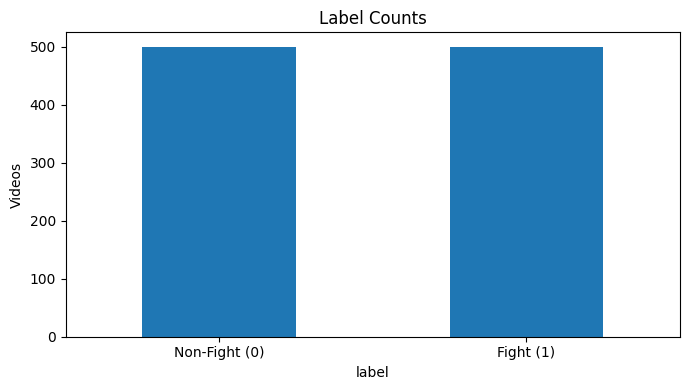

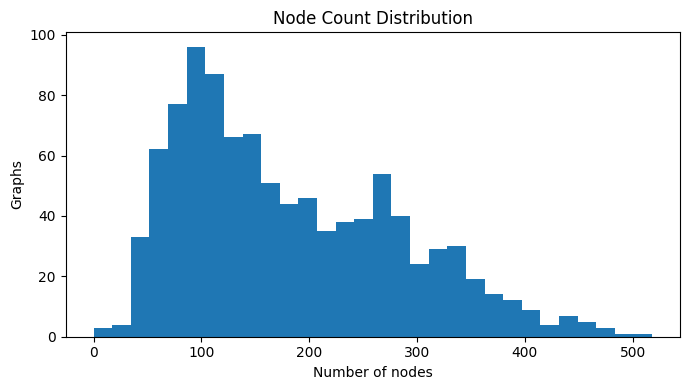

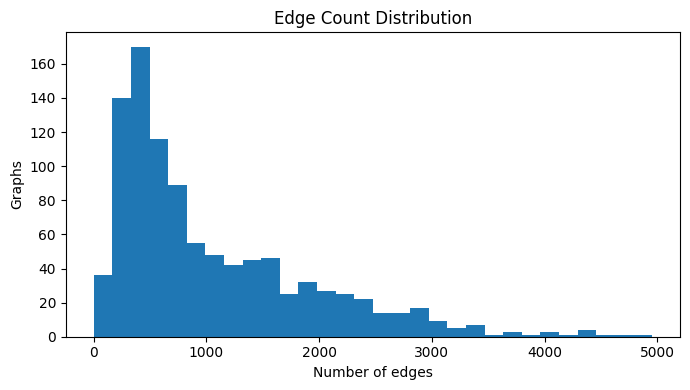

In [11]:
# Cell 11 — Graph statistics plots
plt.figure(figsize=(7, 4))
clean_df["label"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Non-Fight (0)", "Fight (1)"], rotation=0)
plt.title("Label Counts")
plt.ylabel("Videos")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "label_counts.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(clean_df["num_nodes"], bins=30)
plt.title("Node Count Distribution")
plt.xlabel("Number of nodes")
plt.ylabel("Graphs")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "node_count_distribution.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(clean_df["num_edges"], bins=30)
plt.title("Edge Count Distribution")
plt.xlabel("Number of edges")
plt.ylabel("Graphs")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "edge_count_distribution.png", dpi=200)
plt.show()




In [12]:
# Cell 12 — Sample graph inspection
sample_path = Path(clean_df.iloc[0]["graph_path"])
sample = safe_torch_load(sample_path)
print("Sample graph:", sample_path)
print(sample)
print("Node feature names:", sample.node_feature_names)
print("Edge feature names:", sample.edge_feature_names)
print("x shape:", sample.x.shape)
print("edge_index shape:", sample.edge_index.shape)
print("edge_attr shape:", sample.edge_attr.shape)
print("y:", sample.y)
print("\nFirst 5 node rows:")
print(sample.x[:5])




Sample graph: C:\Violence detection\sara_elwakeel\we are really there\we are really there 2\auto_outputs\interaction_only[HF]_2_final_trial_20260419_234156\graphs\no100_xvid.pt
Data(x=[41, 11], edge_index=[2, 158], edge_attr=[158, 4], y=[1], video_id='no100_xvid', video_path='C:\Violence detection\datasets\Hockey fight\data\nofights\no100_xvid.avi', label=0, version_name='v23_final_feature_gated_edges', node_feature_names=[11], edge_feature_names=[4], num_original_frames=41, num_processed_frames=41, nodes_meta=[41])
Node feature names: ['cx', 'cy', 'w', 'h', 't_norm', 'vx_scaled', 'vy_scaled', 'speed_scaled', 'area', 'aspect_ratio_scaled', 'conf']
Edge feature names: ['dt_norm', 'dist_norm', 'edge_type', 'direction']
x shape: torch.Size([41, 11])
edge_index shape: torch.Size([2, 158])
edge_attr shape: torch.Size([158, 4])
y: tensor([0])

First 5 node rows:
tensor([[ 0.5247,  0.5467,  0.5236,  0.5871,  0.0000,  0.0000,  0.0000,  0.0000,  0.3074,  0.1784,  0.9013],
        [ 0.5229,  0.5

In [13]:
# Cell 13 — Split dataset
train_df, temp_df = train_test_split(
    clean_df, test_size=CFG.test_size + CFG.val_size,
    stratify=clean_df["label"], random_state=SEED
)
relative_val_size = CFG.val_size / (CFG.test_size + CFG.val_size)
val_df, test_df = train_test_split(
    temp_df, test_size=1 - relative_val_size,
    stratify=temp_df["label"], random_state=SEED
)
train_df, val_df, test_df = train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)
print("Train:", len(train_df), train_df["label"].value_counts().sort_index().to_dict())
print("Val  :", len(val_df), val_df["label"].value_counts().sort_index().to_dict())
print("Test :", len(test_df), test_df["label"].value_counts().sort_index().to_dict())
train_df.to_csv(OUTPUT_ROOT / "train_split.csv", index=False)
val_df.to_csv(OUTPUT_ROOT / "val_split.csv", index=False)
test_df.to_csv(OUTPUT_ROOT / "test_split.csv", index=False)




Train: 700 {0: 350, 1: 350}
Val  : 150 {0: 75, 1: 75}
Test : 150 {0: 75, 1: 75}


In [14]:
# Cell 14 — Dataset and DataLoaders
class GraphFileDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame):
        super().__init__()
        self.df = dataframe.reset_index(drop=True)
    def len(self):
        return len(self.df)
    def get(self, idx):
        row = self.df.iloc[idx]
        data = safe_torch_load(Path(row["graph_path"]))
        data.y = data.y.long().view(-1)
        return data

train_dataset = GraphFileDataset(train_df)
val_dataset = GraphFileDataset(val_df)
test_dataset = GraphFileDataset(test_df)
train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CFG.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CFG.batch_size, shuffle=False)

batch = next(iter(train_loader))
print(batch)
print("Batch x:", batch.x.shape)
print("Batch edge_attr:", batch.edge_attr.shape)
print("Batch y:", batch.y.shape)




DataBatch(x=[1312, 11], edge_index=[2, 6464], edge_attr=[6464, 4], y=[8], video_id=[8], video_path=[8], label=[8], version_name=[8], node_feature_names=[8], edge_feature_names=[8], num_original_frames=[8], num_processed_frames=[8], nodes_meta=[8], batch=[1312], ptr=[9])
Batch x: torch.Size([1312, 11])
Batch edge_attr: torch.Size([6464, 4])
Batch y: torch.Size([8])


In [25]:
# Cell 15 — Model definition
# Safe final-trial model:
# - Feature-gated motion fusion
# - Edge-aware TransformerConv
# - Residual graph blocks
# - Safe pooling with size=data.num_graphs
# - Handles empty graphs inside a batch correctly

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import TransformerConv, global_mean_pool, global_max_pool


class SafeFeatureGatedMotionGraphTransformer(nn.Module):
    def __init__(
        self,
        in_dim=11,
        hidden_dim=128,
        heads=4,
        edge_dim=4,
        dropout=0.30,
        num_classes=2,
    ):
        super().__init__()

        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        self.heads = heads
        self.edge_dim = edge_dim
        self.dropout = dropout
        self.num_classes = num_classes

        # Node feature order:
        # 0 cx
        # 1 cy
        # 2 w
        # 3 h
        # 4 t_norm
        # 5 vx_scaled
        # 6 vy_scaled
        # 7 speed_scaled
        # 8 area
        # 9 aspect_ratio_scaled
        # 10 conf

        self.register_buffer(
            "base_idx",
            torch.tensor([0, 1, 2, 3, 4, 8, 9, 10], dtype=torch.long),
        )

        self.register_buffer(
            "motion_idx",
            torch.tensor([5, 6, 7], dtype=torch.long),
        )

        self.input_norm = nn.LayerNorm(in_dim)

        self.base_proj = nn.Sequential(
            nn.Linear(8, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.motion_proj = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.motion_gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
        )

        self.conv1 = TransformerConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=edge_dim,
        )

        self.conv2 = TransformerConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=edge_dim,
        )

        self.conv3 = TransformerConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=edge_dim,
        )

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, data):
        x = data.x.float()
        edge_index = data.edge_index.long()
        edge_attr = data.edge_attr.float()
        batch = data.batch

        # Number of graphs in the mini-batch.
        # This can be larger than max(batch)+1 when a graph has zero nodes.
        num_graphs = int(data.num_graphs)

        # If the entire batch has no nodes, return neutral logits.
        if x.size(0) == 0:
            return torch.zeros(
                (num_graphs, self.num_classes),
                dtype=torch.float32,
                device=x.device,
            )

        x = self.input_norm(x)

        base_features = x[:, self.base_idx]
        motion_features = x[:, self.motion_idx]

        base_emb = self.base_proj(base_features)
        motion_emb = self.motion_proj(motion_features)

        gate = self.motion_gate(torch.cat([base_emb, motion_emb], dim=-1))
        h = base_emb + gate * motion_emb

        h1 = self.conv1(h, edge_index, edge_attr)
        h1 = self.bn1(h1)
        h1 = F.relu(h1)
        h1 = F.dropout(h1, p=self.dropout, training=self.training)

        h2 = self.conv2(h1, edge_index, edge_attr)
        h2 = self.bn2(h2)
        h2 = F.relu(h2 + h1)
        h2 = F.dropout(h2, p=self.dropout, training=self.training)

        h3 = self.conv3(h2, edge_index, edge_attr)
        h3 = self.bn3(h3)
        h3 = F.relu(h3 + h2)

        # VERY IMPORTANT:
        # size=num_graphs forces PyG to return one embedding per graph,
        # even if one graph has zero nodes.
        mean_pool = global_mean_pool(h3, batch, size=num_graphs)
        max_pool = global_max_pool(h3, batch, size=num_graphs)

        graph_emb = torch.cat([mean_pool, max_pool], dim=1)
        logits = self.classifier(graph_emb)

        return logits


# Compatibility aliases, in case later cells use older class names.
FeatureGatedMotionGraphTransformer = SafeFeatureGatedMotionGraphTransformer
FeatureGatedMotionGraphTransformerFinal = SafeFeatureGatedMotionGraphTransformer
EdgeAwareSTGraphTransformerFinal = SafeFeatureGatedMotionGraphTransformer

print("Safe model class ready: SafeFeatureGatedMotionGraphTransformer")

Safe model class ready: SafeFeatureGatedMotionGraphTransformer


In [26]:
# Cell 16 — Training/evaluation helper functions
# Fixed to:
# - check logits/y batch alignment
# - support gradient clipping
# - safely compute metrics
# - handle AUC errors if one class is missing in a split/batch

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


def compute_metrics_from_outputs(y_true, y_pred, prob_fight, avg_loss):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    prob_fight = np.asarray(prob_fight)

    metrics = {
        "loss": float(avg_loss),
        "acc": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    try:
        metrics["auc"] = float(roc_auc_score(y_true, prob_fight))
    except ValueError:
        metrics["auc"] = 0.5

    return metrics


def run_epoch(
    model,
    loader,
    optimizer=None,
    criterion=None,
    grad_clip_norm=1.0,
):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_graphs = 0

    all_y_true = []
    all_y_pred = []
    all_prob_fight = []
    all_video_ids = []

    for batch_idx, data in enumerate(loader):
        data = data.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(data)
            y = data.y.view(-1).long()

            # Safety check: catches model/pooling mismatch immediately.
            if logits.size(0) != y.size(0):
                raise ValueError(
                    f"Batch-size mismatch at loader batch {batch_idx}: "
                    f"logits has {logits.size(0)} rows but y has {y.size(0)} labels. "
                    f"data.num_graphs={data.num_graphs}, "
                    f"num_nodes={data.x.size(0)}, "
                    f"edge_attr_shape={tuple(data.edge_attr.shape)}"
                )

            loss = criterion(logits, y)

            if is_train:
                loss.backward()

                if grad_clip_norm is not None:
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        max_norm=grad_clip_norm,
                    )

                optimizer.step()

        probs = F.softmax(logits.detach(), dim=1)[:, 1]
        preds = torch.argmax(logits.detach(), dim=1)

        batch_graphs = y.size(0)
        total_loss += float(loss.detach().cpu().item()) * batch_graphs
        total_graphs += batch_graphs

        all_y_true.extend(y.detach().cpu().numpy().tolist())
        all_y_pred.extend(preds.detach().cpu().numpy().tolist())
        all_prob_fight.extend(probs.detach().cpu().numpy().tolist())

        if hasattr(data, "video_id"):
            # In PyG batching, video_id usually becomes a list.
            if isinstance(data.video_id, (list, tuple)):
                all_video_ids.extend(list(data.video_id))
            else:
                all_video_ids.extend([str(data.video_id)] * batch_graphs)
        else:
            all_video_ids.extend([""] * batch_graphs)

    avg_loss = total_loss / max(total_graphs, 1)

    metrics = compute_metrics_from_outputs(
        y_true=all_y_true,
        y_pred=all_y_pred,
        prob_fight=all_prob_fight,
        avg_loss=avg_loss,
    )

    return metrics, all_y_true, all_y_pred, all_prob_fight


def checkpoint_score_from_metrics(metrics):
    # Precision-aware score for this final trial.
    # We still care about F1 and AUC, but we add precision
    # because the previous V2.2 produced too many false positives.
    return (
        0.50 * metrics["f1"]
        + 0.30 * metrics["auc"]
        + 0.20 * metrics["precision"]
    )


print("Helper functions ready.")

Helper functions ready.


In [27]:
# Cell 17 — Train model
# Uses the safe model class directly.
# This prevents the batch-size mismatch caused by empty graphs inside a batch.

import torch
import torch.nn as nn
import pandas as pd
from dataclasses import asdict

# Final-trial training settings
CFG.dropout = 0.30
CFG.early_stopping_patience = None

MIN_EPOCHS_BEFORE_CHECKPOINT = 5

model = SafeFeatureGatedMotionGraphTransformer(
    in_dim=CFG.expected_node_dim,
    hidden_dim=CFG.hidden_dim,
    heads=CFG.heads,
    edge_dim=CFG.expected_edge_dim,
    dropout=CFG.dropout,
    num_classes=2,
).to(device)

print("Training model class:", model.__class__.__name__)
print("Expected node dim:", CFG.expected_node_dim)
print("Expected edge dim:", CFG.expected_edge_dim)

criterion = nn.CrossEntropyLoss(label_smoothing=getattr(CFG, "label_smoothing", 0.05))

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay,
)

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )
    if CFG.use_scheduler
    else None
)

BEST_MODEL_PATH = RUNS_DIR / "best_model.pt"
HISTORY_CSV = RUNS_DIR / "training_history.csv"

history = []
best_score = -1.0
best_epoch = -1
epochs_without_improvement = 0

for epoch in range(1, CFG.epochs + 1):
    train_metrics, _, _, _ = run_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
    )

    val_metrics, _, _, _ = run_epoch(
        model,
        val_loader,
        optimizer=None,
        criterion=criterion,
    )

    checkpoint_score = checkpoint_score_from_metrics(val_metrics)

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "checkpoint_score": checkpoint_score,
        "lr": optimizer.param_groups[0]["lr"],
        "checkpoint_allowed": epoch >= MIN_EPOCHS_BEFORE_CHECKPOINT,
    }

    history.append(row)

    print(
        f"Epoch {epoch:03d} Train | "
        f"loss={train_metrics['loss']:.4f} | "
        f"acc={train_metrics['acc']:.4f} | "
        f"precision={train_metrics['precision']:.4f} | "
        f"recall={train_metrics['recall']:.4f} | "
        f"f1={train_metrics['f1']:.4f} | "
        f"auc={train_metrics['auc']:.4f}"
    )

    print(
        f"Epoch {epoch:03d} Val   | "
        f"loss={val_metrics['loss']:.4f} | "
        f"acc={val_metrics['acc']:.4f} | "
        f"precision={val_metrics['precision']:.4f} | "
        f"recall={val_metrics['recall']:.4f} | "
        f"f1={val_metrics['f1']:.4f} | "
        f"auc={val_metrics['auc']:.4f} | "
        f"score={checkpoint_score:.4f} | "
        f"checkpoint_allowed={epoch >= MIN_EPOCHS_BEFORE_CHECKPOINT}"
    )

    print("-" * 100)

    if scheduler is not None:
        scheduler.step(checkpoint_score)

    if epoch >= MIN_EPOCHS_BEFORE_CHECKPOINT:
        if checkpoint_score > best_score:
            best_score = checkpoint_score
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "cfg": asdict(CFG),
                    "best_epoch": best_epoch,
                    "best_score": best_score,
                    "val_metrics": val_metrics,
                    "model_class": model.__class__.__name__,
                    "min_epochs_before_checkpoint": MIN_EPOCHS_BEFORE_CHECKPOINT,
                },
                BEST_MODEL_PATH,
            )
        else:
            epochs_without_improvement += 1

    if CFG.early_stopping_patience is not None:
        if epoch >= MIN_EPOCHS_BEFORE_CHECKPOINT:
            if epochs_without_improvement >= CFG.early_stopping_patience:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

# Safety fallback if no checkpoint was saved.
if best_epoch == -1:
    best_epoch = epoch
    best_score = checkpoint_score

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "cfg": asdict(CFG),
            "best_epoch": best_epoch,
            "best_score": best_score,
            "val_metrics": val_metrics,
            "model_class": model.__class__.__name__,
            "min_epochs_before_checkpoint": MIN_EPOCHS_BEFORE_CHECKPOINT,
            "note": "Fallback final-epoch checkpoint because no best checkpoint was saved.",
        },
        BEST_MODEL_PATH,
    )

history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_CSV, index=False)

print("Output dir:", OUTPUT_ROOT)
print("Best epoch:", best_epoch)
print("Best checkpoint score:", best_score)
print("Best checkpoint:", BEST_MODEL_PATH)
print("History saved:", HISTORY_CSV)
print("Dropout used:", CFG.dropout)
print("Minimum checkpoint epoch:", MIN_EPOCHS_BEFORE_CHECKPOINT)
print("Early stopping patience:", CFG.early_stopping_patience)

Training model class: SafeFeatureGatedMotionGraphTransformer
Expected node dim: 11
Expected edge dim: 4
Epoch 001 Train | loss=0.6734 | acc=0.7414 | precision=0.7341 | recall=0.7571 | f1=0.7454 | auc=0.8021
Epoch 001 Val   | loss=0.3184 | acc=0.8933 | precision=0.8734 | recall=0.9200 | f1=0.8961 | auc=0.9575 | score=0.9100 | checkpoint_allowed=False
----------------------------------------------------------------------------------------------------
Epoch 002 Train | loss=0.4899 | acc=0.8171 | precision=0.8016 | recall=0.8429 | f1=0.8217 | auc=0.8689
Epoch 002 Val   | loss=0.2777 | acc=0.9000 | precision=0.8947 | recall=0.9067 | f1=0.9007 | auc=0.9653 | score=0.9189 | checkpoint_allowed=False
----------------------------------------------------------------------------------------------------
Epoch 003 Train | loss=0.4581 | acc=0.8400 | precision=0.8324 | recall=0.8514 | f1=0.8418 | auc=0.8956
Epoch 003 Val   | loss=0.3317 | acc=0.9000 | precision=0.9054 | recall=0.8933 | f1=0.8993 | auc

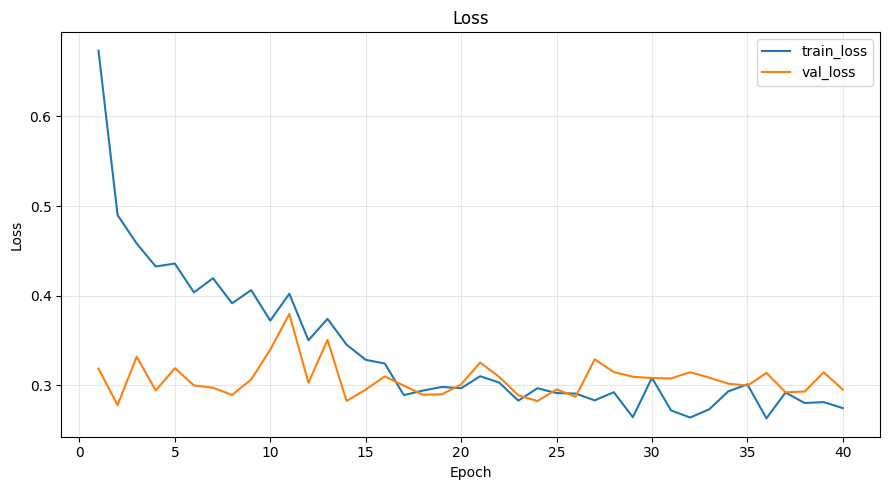

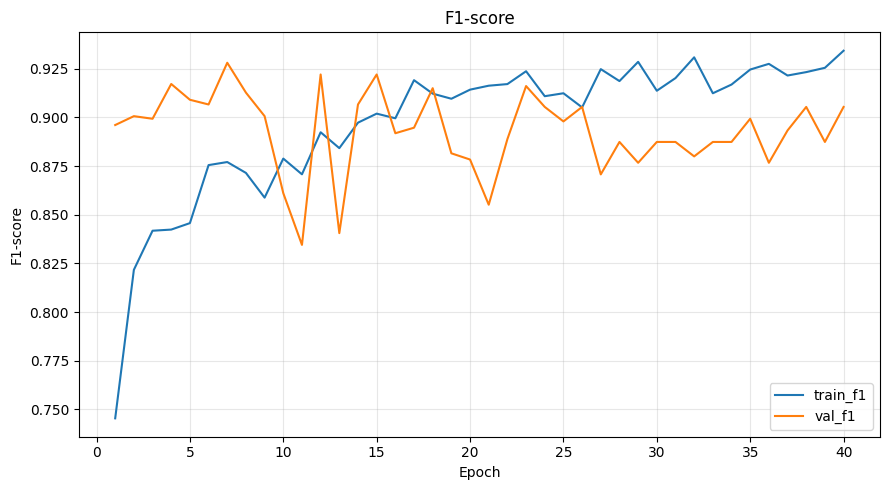

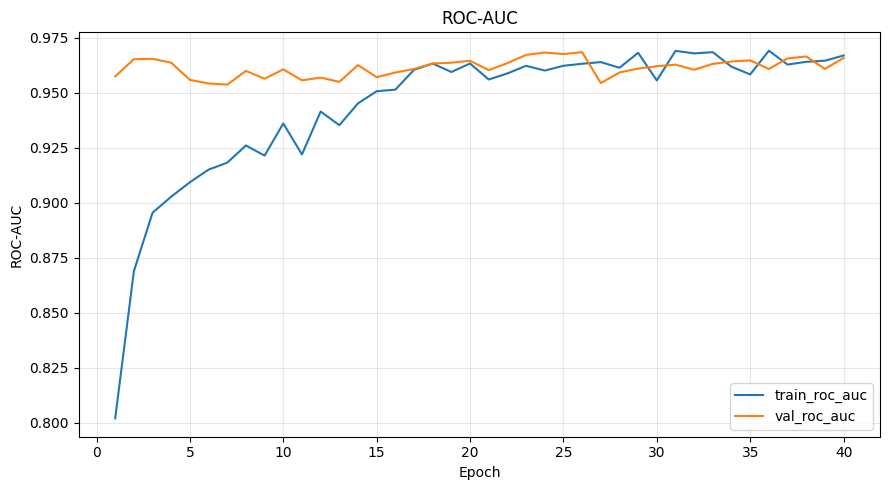

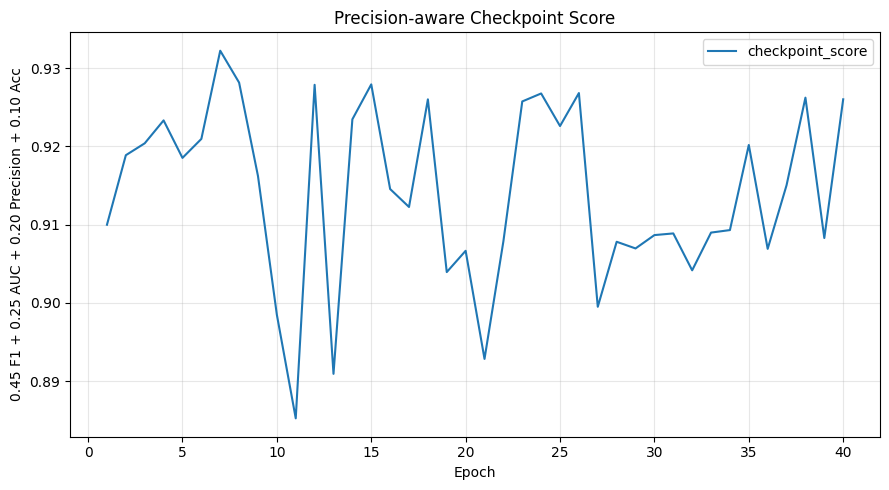

In [28]:
# Cell 18 — Training curves
history_df = pd.read_csv(HISTORY_CSV)

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(PLOTS_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_f1"], label="train_f1")
plt.plot(history_df["epoch"], history_df["val_f1"], label="val_f1")
plt.xlabel("Epoch"); plt.ylabel("F1-score"); plt.title("F1-score"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(PLOTS_DIR / "f1_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_auc"], label="train_roc_auc")
plt.plot(history_df["epoch"], history_df["val_auc"], label="val_roc_auc")
plt.xlabel("Epoch"); plt.ylabel("ROC-AUC"); plt.title("ROC-AUC"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(PLOTS_DIR / "auc_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["checkpoint_score"], label="checkpoint_score")
plt.xlabel("Epoch")
plt.ylabel("0.45 F1 + 0.25 AUC + 0.20 Precision + 0.10 Acc")
plt.title("Precision-aware Checkpoint Score")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(PLOTS_DIR / "checkpoint_score_curve.png", dpi=200)
plt.show()






In [29]:
# Cell 19 — Validation threshold tuning and final test evaluation
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
print("Loaded best checkpoint from epoch:", checkpoint["best_epoch"])
print("Best checkpoint score:", checkpoint["best_score"])

val_default_metrics, val_true_default, val_pred_default, val_prob_default = evaluate_with_threshold(
    model, val_loader, threshold=0.5, criterion=criterion
)
print("\nValidation metrics with default threshold 0.5:")
print(val_default_metrics)

best_threshold, best_threshold_row, threshold_df, threshold_mode = find_best_threshold_precision_aware(
    val_true_default,
    val_prob_default,
)

THRESHOLD_SEARCH_CSV = RUNS_DIR / "threshold_search_validation.csv"
threshold_df.to_csv(THRESHOLD_SEARCH_CSV, index=False)

val_tuned_metrics, val_true, val_pred, val_prob = evaluate_with_threshold(
    model, val_loader, threshold=best_threshold, criterion=criterion
)
print(f"\nBest validation threshold: {best_threshold:.3f}")
print("Threshold selection mode:", threshold_mode)
print("Best threshold row:")
print(best_threshold_row)
print("Validation metrics with tuned threshold:")
print(val_tuned_metrics)

THRESHOLD_JSON = RUNS_DIR / "best_threshold.json"
with open(THRESHOLD_JSON, "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_threshold": best_threshold,
            "threshold_selection_mode": threshold_mode,
            "best_threshold_row": best_threshold_row,
            "val_default_metrics": val_default_metrics,
            "val_tuned_metrics": val_tuned_metrics,
            "threshold_min_precision": CFG.threshold_min_precision,
            "threshold_min_recall": CFG.threshold_min_recall,
        },
        f,
        indent=2,
    )

test_metrics, test_true, test_pred, test_prob = evaluate_with_threshold(
    model, test_loader, threshold=best_threshold, criterion=criterion
)
print("\nFinal test metrics with validation-tuned threshold:")
print(test_metrics)
print("Threshold used:", best_threshold)

TEST_METRICS_JSON = RUNS_DIR / "test_metrics.json"
with open(TEST_METRICS_JSON, "w", encoding="utf-8") as f:
    json.dump(
        {
            "threshold_used": best_threshold,
            "threshold_selection_mode": threshold_mode,
            "test_metrics": test_metrics,
            "best_epoch": checkpoint["best_epoch"],
            "best_checkpoint_score": checkpoint["best_score"],
        },
        f,
        indent=2,
    )

pred_df = test_df.copy()
pred_df["true_label"] = test_true
pred_df["pred_label"] = test_pred
pred_df["prob_fight"] = test_prob
PRED_CSV = RUNS_DIR / "test_predictions.csv"
pred_df.to_csv(PRED_CSV, index=False)

print("Threshold info saved to:", THRESHOLD_JSON)
print("Threshold search CSV saved to:", THRESHOLD_SEARCH_CSV)
print("Test metrics saved to:", TEST_METRICS_JSON)
print("Test predictions saved to:", PRED_CSV)
display(pred_df[["video_id", "video_path", "true_label", "pred_label", "prob_fight"]].head())






Loaded best checkpoint from epoch: 7
Best checkpoint score: 0.9322369029663147

Validation metrics with default threshold 0.5:
{'acc': 0.9266666666666666, 'precision': 0.9102564102564102, 'recall': 0.9466666666666667, 'f1': 0.9281045751633987, 'auc': 0.9537777777777777, 'loss': 0.3010803821839784}

Best validation threshold: 0.520
Threshold selection mode: precision_recall_constrained
Best threshold row:
{'threshold': 0.5200000000000001, 'acc': 0.9333333333333333, 'precision': 0.922077922077922, 'recall': 0.9466666666666667, 'f1': 0.9342105263157895, 'auc': 0.9537777777777777, 'selection_score': 0.9310457963089541}
Validation metrics with tuned threshold:
{'acc': 0.9333333333333333, 'precision': 0.922077922077922, 'recall': 0.9466666666666667, 'f1': 0.9342105263157895, 'auc': 0.9537777777777777, 'loss': 0.3010803868896083}

Final test metrics with validation-tuned threshold:
{'acc': 0.92, 'precision': 0.9436619718309859, 'recall': 0.8933333333333333, 'f1': 0.9178082191780822, 'auc': 0.

,video_id,video_path,true_label,pred_label,prob_fight
0,no397_xvid,C:\Violence detection\datasets\Hockey fight\da...,0,0,0.029388
1,fi351_xvid,C:\Violence detection\datasets\Hockey fight\da...,1,1,0.907164
2,fi300_xvid,C:\Violence detection\datasets\Hockey fight\da...,1,1,0.907175
3,fi186_xvid,C:\Violence detection\datasets\Hockey fight\da...,1,1,0.682405
4,fi436_xvid,C:\Violence detection\datasets\Hockey fight\da...,1,0,0.359691


Confusion matrix:
[[71  4]
 [ 8 67]]

Classification report:
              precision    recall  f1-score   support

   Non-Fight     0.8987    0.9467    0.9221        75
       Fight     0.9437    0.8933    0.9178        75

    accuracy                         0.9200       150
   macro avg     0.9212    0.9200    0.9199       150
weighted avg     0.9212    0.9200    0.9199       150



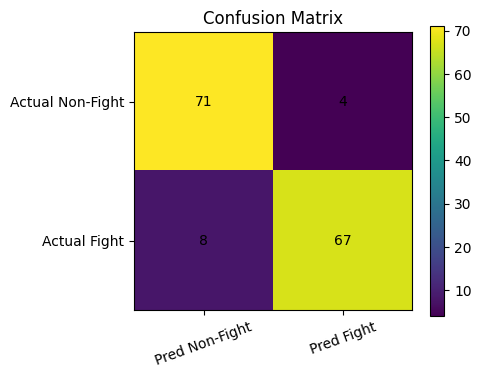

In [30]:
# Cell 20 — Confusion matrix and classification report
cm = confusion_matrix(test_true, test_pred)
print("Confusion matrix:")
print(cm)
print("\nClassification report:")
print(classification_report(test_true, test_pred, target_names=["Non-Fight", "Fight"], digits=4))

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks([0, 1], ["Pred Non-Fight", "Pred Fight"], rotation=20)
plt.yticks([0, 1], ["Actual Non-Fight", "Actual Fight"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrix.png", dpi=200)
plt.show()




In [31]:
# Cell 21 — Save final experiment summary
summary = {
    "experiment_name": CFG.experiment_name,
    "version_name": CFG.version_name,
    "run_tag": RUN_TAG,
    "dataset_root": CFG.dataset_root,
    "output_root": str(OUTPUT_ROOT),
    "total_clean_graphs": int(len(clean_df)),
    "label_counts": {str(k): int(v) for k, v in clean_df["label"].value_counts().sort_index().items()},
    "node_feature_names": NODE_FEATURE_NAMES,
    "edge_feature_names": EDGE_FEATURE_NAMES,
    "model": "FeatureGatedResidualSTGraphTransformer",
    "best_epoch": int(checkpoint["best_epoch"]),
    "best_checkpoint_score": float(checkpoint["best_score"]),
    "best_threshold": float(best_threshold),
    "threshold_selection_mode": threshold_mode,
    "test_metrics": test_metrics,
    "confusion_matrix": cm.tolist(),
    "final_trial_improvements": [
        "automatic timestamped output folder",
        "scaled motion node features",
        "4D edge attributes: dt_norm, dist_norm, edge_type, direction",
        "feature-gated node input fusion",
        "residual TransformerConv blocks",
        "label smoothing",
        "gradient clipping",
        "precision-aware checkpoint score",
        "precision-constrained validation threshold search",
    ],
    "files": {
        "clean_index": str(CLEAN_INDEX_CSV),
        "best_model": str(BEST_MODEL_PATH),
        "history_csv": str(HISTORY_CSV),
        "test_predictions_csv": str(PRED_CSV),
        "test_metrics_json": str(TEST_METRICS_JSON),
        "threshold_json": str(THRESHOLD_JSON),
        "threshold_search_csv": str(THRESHOLD_SEARCH_CSV),
        "plots_dir": str(PLOTS_DIR),
    },
}

SUMMARY_JSON = OUTPUT_ROOT / "experiment_summary.json"
with open(SUMMARY_JSON, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Experiment summary saved to:", SUMMARY_JSON)
print("\nFinal test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")






Experiment summary saved to: C:\Violence detection\sara_elwakeel\we are really there\we are really there 2\auto_outputs\interaction_only[HF]_2_final_trial_20260419_234156\experiment_summary.json

Final test metrics:
acc: 0.9200
precision: 0.9437
recall: 0.8933
f1: 0.9178
auc: 0.9689
loss: 0.2740


## How outputs are saved automatically

This notebook automatically creates one timestamped folder per run under:

```text
C:\Violence detection\sara_elwakeel\we are really there\we are really there 2\auto_outputs
```

The folder name follows this pattern:

```text
interaction_only[HF]_2_final_trial_YYYYMMDD_HHMMSS
```

Inside it, the notebook saves:

- `graphs/` — generated PyTorch Geometric graph files
- `training_outputs/` — model checkpoint, metrics JSON files, predictions CSV, threshold search CSV, and training history
- `plots/` — training curves and graph statistics
- `clean_verified_index.csv`
- `experiment_summary.json`

Because this final trial changes the edge feature dimension from 2 to 4, it must generate a fresh graph folder. Do not mix these graphs with V1, V2, V2.1, or V2.2 graph files.

